# Clase 1 · Laboratorio — Explorando Saber 11

**Trabajo en parejas · 90 min.**

Al final deben tener un notebook completado con las 5 tareas resueltas y subirlo a Moodle antes de las 23:59 del día de clase.

**Checkpoint conjunto a los 45 min:** el profesor detiene la sala y resolvemos juntos cualquier duda de la Tarea 3. Sigan al ritmo del reloj.

In [1]:
!pip3 install --user pyarrow
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../../datos/saber11_muestra_500k.csv")
print(f"Cargados {len(df):,} registros")

Cargados 500,000 registros

## Tarea 1 (10 min) — Perfil del dataset

Completa las siguientes celdas para responder:
- ¿Cuántos años cubre el dataset?
- ¿Cuál es el rango del PUNT_GLOBAL (mínimo, máximo, media)?
- ¿Qué porcentaje de estudiantes viene de colegios oficiales vs no oficiales?

In [2]:
# años cubiertos
# OJO: PERIODO viene como AAAAS (año + semestre, ej. 20194 = 2019 semestre 2),
# por eso extraemos los primeros 4 caracteres para quedarnos con el año.
anos = sorted(df['PERIODO'].astype(str).str[:4].unique())
print(anos)

# rango de PUNT_GLOBAL
resumen_punt = df['PUNT_GLOBAL'].agg(['min', 'max', 'mean']).round(2)
print(resumen_punt)

# distribución de COLE_NATURALEZA
distribucion_naturaleza = df['COLE_NATURALEZA'].value_counts(normalize=True).mul(100).round(1)
print(distribucion_naturaleza)

['2019', '2022']
min       0.00
max     472.00
mean    248.14
Name: PUNT_GLOBAL, dtype: float64
COLE_NATURALEZA
OFICIAL       76.9
NO OFICIAL    23.1
Name: proportion, dtype: float64

## Tarea 2 (15 min) — Comparación por estrato

Produce una gráfica que compare la distribución de `PUNT_GLOBAL` entre los estratos de vivienda. Elige el tipo de gráfica más adecuado y justifica tu elección en Markdown debajo.

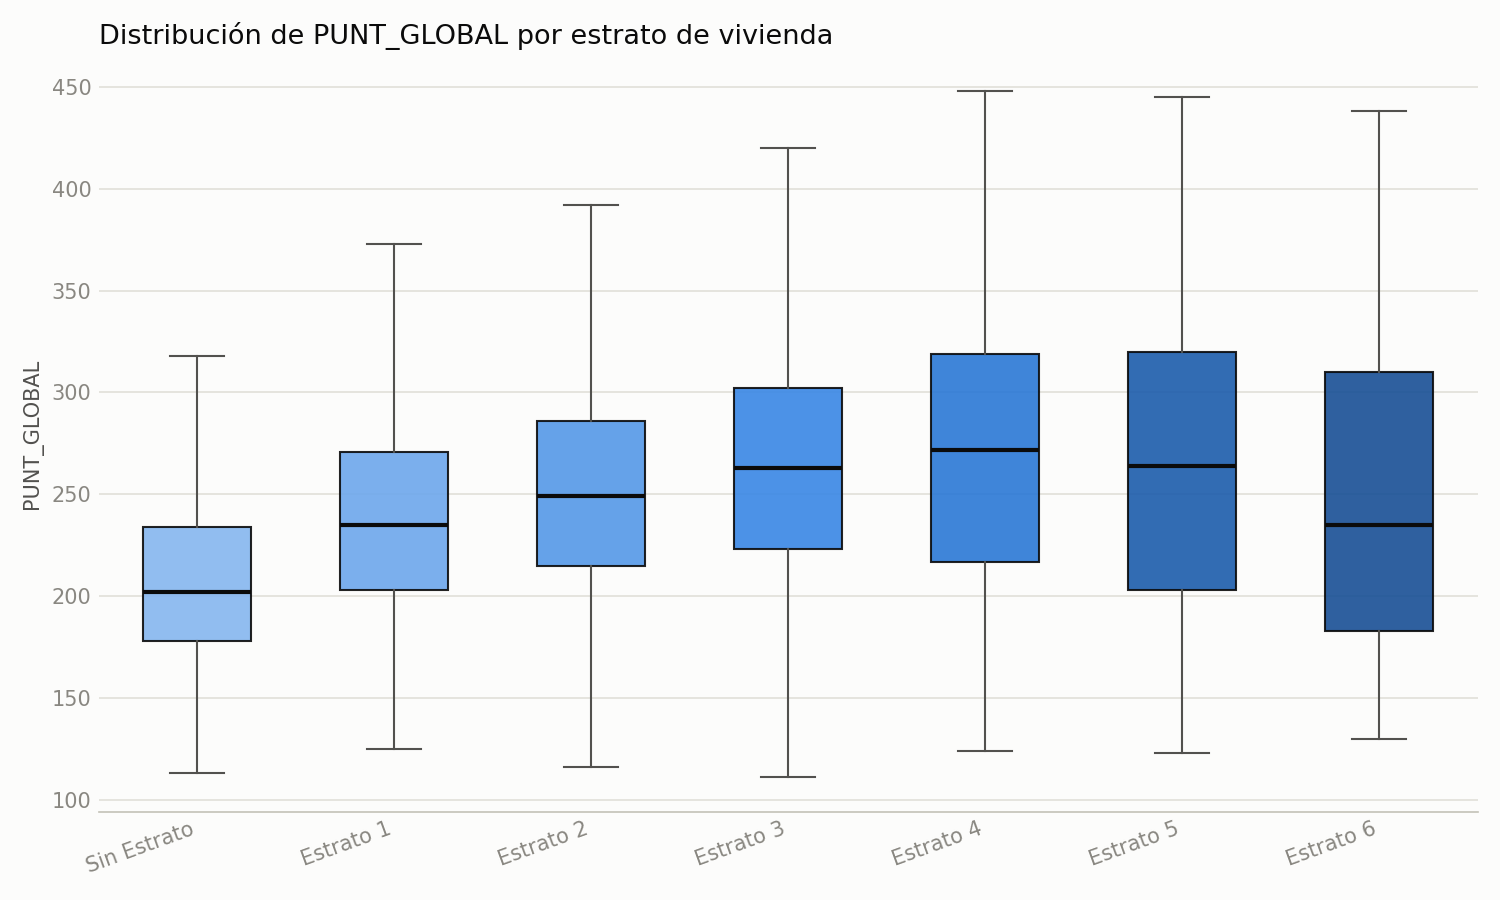

In [3]:
# La variable de estrato es FAMI_ESTRATOVIVIENDA (categórica ordinal: Sin Estrato, Estrato 1..6).
# Usamos boxplot porque es ordinal y numérica: muestra mediana, dispersión y outliers
# por grupo, algo que un gráfico de barras de promedios ocultaría.
orden = ['Sin Estrato', 'Estrato 1', 'Estrato 2', 'Estrato 3', 'Estrato 4', 'Estrato 5', 'Estrato 6']
orden = [e for e in orden if e in df['FAMI_ESTRATOVIVIENDA'].dropna().unique()]

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='FAMI_ESTRATOVIVIENDA', y='PUNT_GLOBAL', order=orden, showfliers=False)
plt.xticks(rotation=20, ha='right')
plt.title('Distribución de PUNT_GLOBAL por estrato de vivienda')
plt.tight_layout()
plt.show()

_(Justifica tu elección de gráfica acá):_

Elegimos un boxplot porque `FAMI_ESTRATOVIVIENDA` es una variable ordinal y `PUNT_GLOBAL` es numérica continua: el boxplot muestra mediana, rango intercuartílico y dispersión por grupo, no solo el promedio. Con los datos reales se ve una tendencia creciente de la mediana desde "Sin Estrato" (≈202 puntos) hasta Estrato 4 (≈272 puntos), y luego una leve caída en Estrato 5 y 6 que probablemente se debe al tamaño de muestra mucho menor en esos grupos (7,820 y 3,608 registros frente a >100,000 en los estratos bajos).

## Tarea 3 (20 min) — Brecha urbano-rural

Crea una tabla que muestre el promedio de PUNT_GLOBAL por combinación de:
- COLE_DEPTO_UBICACION (10 departamentos con más registros)
- COLE_NATURALEZA (Oficial vs No oficial)

Comenta 2 hallazgos en 3-4 frases.

In [4]:
# Pistas: usa .groupby([...]).mean() y luego .unstack() para tabla pivote.
# Filtra a los 10 departamentos con más registros primero.
top10 = df['COLE_DEPTO_UBICACION'].value_counts().head(10).index

subset = df[df['COLE_DEPTO_UBICACION'].isin(top10)]
tabla = (
    subset.groupby(['COLE_DEPTO_UBICACION', 'COLE_NATURALEZA'])['PUNT_GLOBAL']
    .mean()
    .unstack()
    .round(1)
)
tabla['BRECHA'] = (tabla['NO OFICIAL'] - tabla['OFICIAL']).round(1)
tabla = tabla.sort_values('BRECHA', ascending=False)
tabla

COLE_NATURALEZA       NO OFICIAL  OFICIAL  BRECHA
COLE_DEPTO_UBICACION                             
BOLIVAR                    268.6    219.5    49.1
MAGDALENA                  260.5    220.0    40.5
CORDOBA                    261.6    232.4    29.2
BOGOTÁ                     284.3    255.9    28.4
CUNDINAMARCA               274.1    250.6    23.5
ANTIOQUIA                  258.6    240.2    18.4
SANTANDER                  279.1    260.8    18.3
ATLANTICO                  253.4    239.4    14.0
NARIÑO                     254.8    244.3    10.5
VALLE                      251.0    243.6     7.4

_(Hallazgos de la tabla — 2 hallazgos en 3-4 frases):_

1. La brecha entre colegios oficiales y no oficiales varía fuertemente por departamento: en Bolívar es de 49.1 puntos (269 vs. 220) y en Magdalena de 40.5 puntos, mientras que en Valle del Cauca es de solo 7.4 puntos. Esto sugiere que la brecha no es un fenómeno nacional uniforme, sino que está concentrada en departamentos específicos, posiblemente por diferencias en la calidad o cobertura de la oferta educativa oficial local.
2. Bogotá y Cundinamarca tienen los promedios más altos tanto en oficial como en no oficial (255.9 y 250.6 en oficial, respectivamente), lo que indica que incluso el colegio oficial promedio en la región central del país supera al no oficial promedio de varios departamentos de la costa Caribe, reflejando desigualdades regionales que van más allá del tipo de colegio.

## ⏸ Checkpoint del profesor (10 min)

Detengan aquí. El profesor revisa dudas de las Tareas 1-3 con toda la sala. Después, continúen.

## Tarea 4 (20 min) — Preguntas de negocio

Escribe 3 preguntas de negocio que este dataset podría responder. Para cada una, indica qué variable(s) usarías y qué tipo de análisis harías (descriptivo, predictivo, prescriptivo).

1. **Pregunta:** ¿Qué tan grande es la brecha de puntaje entre colegios oficiales y no oficiales en cada departamento, y en cuáles es más urgente cerrarla?
   - Variables: `PUNT_GLOBAL`, `COLE_NATURALEZA`, `COLE_DEPTO_UBICACION`
   - Tipo: descriptivo
2. **Pregunta:** ¿Se puede predecir el `PUNT_GLOBAL` de un estudiante a partir de su contexto socioeconómico y el colegio al que asiste?
   - Variables: `PUNT_GLOBAL` (objetivo), `FAMI_ESTRATOVIVIENDA`, `FAMI_EDUCACIONMADRE`, `FAMI_EDUCACIONPADRE`, `FAMI_TIENEINTERNET`, `COLE_NATURALEZA`, `COLE_AREA_UBICACION`
   - Tipo: predictivo
3. **Pregunta:** ¿En qué departamentos y para qué tipo de colegio debería el Ministerio de Educación priorizar recursos (conectividad, capacitación docente) para cerrar la brecha oficial/no oficial identificada en la Tarea 3?
   - Variables: `PUNT_GLOBAL`, `COLE_DEPTO_UBICACION`, `COLE_NATURALEZA`, `FAMI_TIENEINTERNET`, `FAMI_TIENECOMPUTADOR`
   - Tipo: prescriptivo

## Tarea 5 (25 min) — Primer boceto del dataset del proyecto

Con tu grupo (los mismos que serán tu grupo del proyecto):
1. Confirmen la elección del dataset del catálogo.
2. Descarguen el CSV del dataset de fuente oficial.
3. Cárguenlo con `pandas.read_csv(...)` en la celda siguiente.
4. Reporten: filas, columnas, tipos, ¿tienen la variable objetivo esperada?

In [5]:
# El CSV de siniestralidad viene con separador ";" y codificación latin-1
# (no utf-8), y usa "." como marcador de dato faltante en varias columnas.
# Con read_csv por defecto (sep=",", utf-8) esto falla o se lee mal.
df_proyecto = pd.read_csv("../../datos/siniestralidad_2016_2024.csv", sep=";", encoding="latin-1")
df_proyecto.info()

print()
print("Filas x columnas:", df_proyecto.shape)
print()
print("Distribución de la variable objetivo propuesta (Tipo confirmado):")
print(df_proyecto["Tipo confirmado"].value_counts(dropna=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 371003 entries, 0 to 371002
Data columns (total 10 columns):
 #   Column                         Non-Null Count   Dtype 
---  ------                         --------------   ----- 
 0   Código                         371002 non-null  object
 1   Fecha                          371002 non-null  object
 2   Tipo confirmado                371002 non-null  object
 3   Dirección reporte              189410 non-null  object
 4   Tipo clase de accidente        371002 non-null  object
 5   Tipo clase de accidente.1      371002 non-null  object
 6   Tipo confirmado.1              371003 non-null  object
 7   Medio de reporte               371003 non-null  object
 8   Numero vehículos               371003 non-null  object
 9   Tipo de vehículos implicados   371003 non-null  object
dtypes: object(10)
memory usage: 28.3+ MB

Filas x columnas: (371003, 10)

Distribución de la variable objetivo propuesta (Tipo confirmado):
Tipo confirmado
Negativo    

**Reporte del dataset del proyecto — Siniestralidad vial 2016-2024**

- **Filas:** 371,003 registros de siniestros viales.
- **Columnas:** 10 — `Código`, `Fecha`, `Tipo confirmado`, `Dirección reporte`, `Tipo clase de accidente` (aparece duplicada como `Tipo clase de accidente.1`), `Tipo confirmado.1`, `Medio de reporte`, `Numero vehículos`, `Tipo de vehículos implicados`.
- **Tipos:** `pandas` carga las 10 columnas como `object` (texto). En realidad `Fecha` debería convertirse a `datetime` y `Numero vehículos` a numérico; ambas vienen como texto porque el archivo usa "." como marcador de dato faltante en vez de dejar la celda vacía, lo que rompe la detección automática de tipo de `pandas`.
- **Variable objetivo esperada:** SÍ está presente. Proponemos `Tipo confirmado` como variable objetivo para un modelo de clasificación de gravedad del siniestro (Negativo / Solo daños / Con lesionado / Con fallecido).

**Hallazgos de calidad de datos a tener en cuenta antes de modelar:**

1. Hay columnas duplicadas con contenido inconsistente entre sí: `Tipo confirmado` viene limpia (con tildes correctas), mientras que `Tipo confirmado.1` parece exportada con otra codificación (aparecen valores como "Solo Da?os" en vez de "Solo Daños") y usa categorías más granulares (23 valores distintos vs. 7 en la columna limpia). Lo mismo pasa con `Tipo clase de accidente` y su duplicado.
2. `Dirección reporte` tiene cerca de 182,000 valores nulos (~49% de las filas), así que cualquier análisis geográfico tendría que trabajar con poco más de la mitad del dataset.
3. Las categorías de texto no están normalizadas: `Tipo confirmado` mezcla "Solo daños" y "Solo Daños" como si fueran categorías distintas, y `Medio de reporte` tiene variantes como "TELEF?NICO 127" y "TELEF?NICO127" que en realidad son el mismo medio. Antes de entrenar cualquier modelo habría que unificar mayúsculas/tildes y agrupar estas variantes.

## Entrega

- Suban este notebook completado a Moodle antes de las 23:59.
- Nombre: `Urrego_Gomez-Garcia_Viera_clase01_lab.ipynb`.